In [1]:
import sys

sys.path.insert(0, "..")

import time
from configparser import ConfigParser

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

from src.core.kernels import compute_kernel
from src.core.models.multivar_gp.dense_gp import DenseGP
from src.core.models.multivar_gp.fitc_gp import FITCGP
from src.utils.inducing_point_selectors import get_inducing_selector

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)


def make_config(
    kernel="RBF",
    lmbda=0.01,
    alpha=1.0,
    use_sparse=False,
    num_inducing=20,
    inducing_method="kmeans",
):
    cfg = ConfigParser()
    cfg["KERNEL"] = {"type": kernel, "lmbda": str(lmbda), "alpha": str(alpha)}
    cfg["SPARSE"] = {
        "use_sparse": str(use_sparse).lower(),
        "num_inducing": str(num_inducing),
        "inducing_method": inducing_method,
    }
    return cfg

# Gaussian Processes

A GP is a distribution over functions, parameterised by:

- A **mean function** $m(x)$ (usually $0$)
- A **kernel** $k(x, x')$

For any finite set of inputs $x_1, \ldots, x_n$, the function values are jointly Gaussian:

$$(f(x_1), \ldots, f(x_n)) \sim \mathcal{N}(\mathbf{m}, K), \quad K_{ij} = k(x_i, x_j)$$

The kernel encodes what functions the GP considers plausible, (smoothness, amplitude, characteristic length scales). It must be +ve definite (every Gram matrix $K$ is +ve semi-definite) so the Gaussian above is well-defined.

### The RBF kernel

$$k(x, x') = \exp\!\left(-\frac{1}{2}\sum_{i=1}^d \frac{(x_i - x'_i)^2}{\sigma_i^2}\right)$$

$\sigma_i$ is the **length scale** in dimension $i$: how far you move before $f$ changes a notable amount. Small $\sigma$ -> rapid, large $\sigma$ -> slow. Having a separate $\sigma_i$ per dimension is **ARD** (automatic relevance determination). A large $\sigma_i$ means the function barely depends on dimension $i$.

Below are function samples from the prior using RBF GPs with different length scales. This is what the GP expects before seeing data.

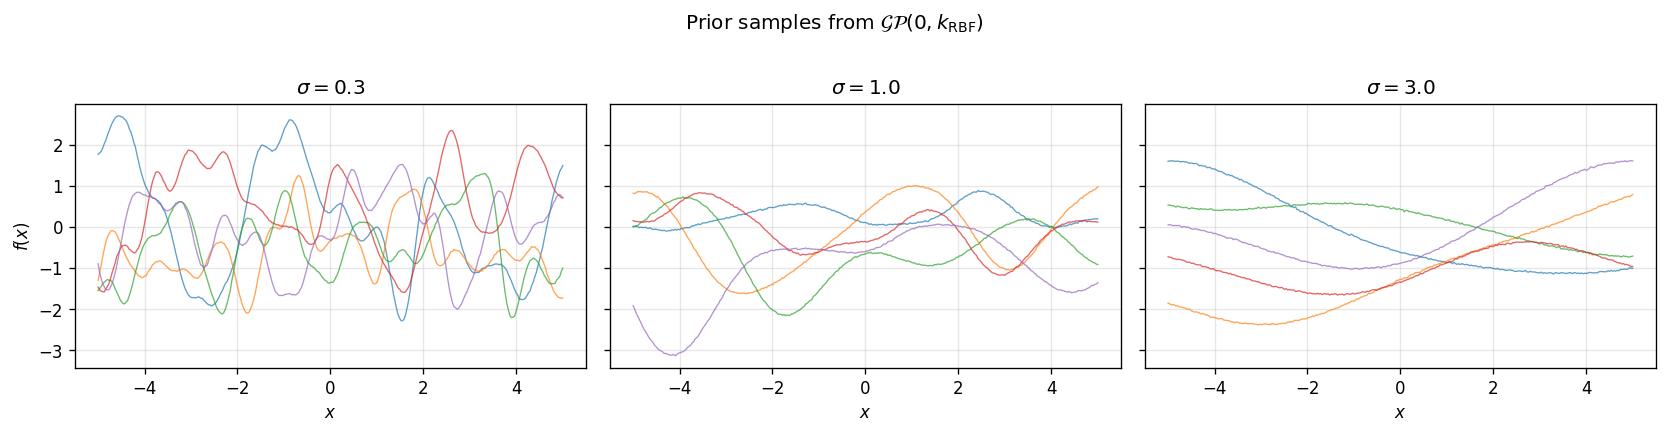

In [2]:
np.random.seed(0)
X_grid = np.linspace(-5, 5, 300).reshape(-1, 1)
sigmas_prior = [0.3, 1.0, 3.0]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, sig in zip(axes, sigmas_prior):
    K = np.array(
        compute_kernel("RBF", X_grid, X_grid, np.array([sig])), dtype=np.float64
    )
    K += 1e-4 * np.eye(len(X_grid))
    L = np.linalg.cholesky(K)
    for _ in range(5):
        ax.plot(X_grid, L @ np.random.randn(len(X_grid)), linewidth=0.8, alpha=0.7)
    ax.set_title(rf"$\sigma = {sig}$")
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$f(x)$")
plt.suptitle(r"Prior samples from $\mathcal{GP}(0, k_{\mathrm{RBF}})$", y=1.02)
plt.tight_layout()
plt.show()

## Regression

We observe $n$ noisy evaluations $y_i = f(x_i) + \varepsilon_i$ with $\varepsilon_i \sim \mathcal{N}(0, \lambda)$ (aleatoric noise), and want to predict $f$ at new inputs $X_*$.

The prior is Gaussian, the noise is Gaussian, so the joint is Gaussian:

$$\begin{pmatrix} \mathbf{y} \\ \mathbf{f}_* \end{pmatrix} \sim \mathcal{N}\!\left(\mathbf{0},\; \begin{pmatrix} K + \lambda I & K_{n*} \\ K_{*n} & K_{**} \end{pmatrix}\right)$$

where $K = k(X, X)$, $K_{n*} = k(X, X_*)$, $K_{**} = k(X_*, X_*)$.

Conditioning $\mathbf{f}_*$ on $\mathbf{y}$ (standard result for partitioned Gaussians, find by joint density -> complete the square in $\mathbf{f}_*$):

$$\mathbf{f}_* \mid \mathbf{y} \sim \mathcal{N}(\boldsymbol{\mu}_*, \Sigma_*)$$

$$\boldsymbol{\mu}_* = K_{*n}(K + \lambda I)^{-1}\mathbf{y}$$

$$\Sigma_* = K_{**} - K_{*n}(K + \lambda I)^{-1}K_{n*}$$

$\boldsymbol{\mu}_*$ is the prediction. $\text{diag}(\Sigma_*)$ gives the epistemic uncertainty at each test point (what we lack knowledge about $f$). To get predictive variance for a new observation $y_*$, add back the aleatoric term: $\text{Var}(y_*) = \Sigma_* + \lambda I$.

- **Posterior variance depends what input locations have been explored**, not on $\mathbf{y}$. Where we have data, we're confident regardless of what $\mathbf{y}$ is.
- **The posterior mean is linear in $\mathbf{y}$**: the weights $(K + \lambda I)^{-1}$ depend on the input geometry, not the outputs.

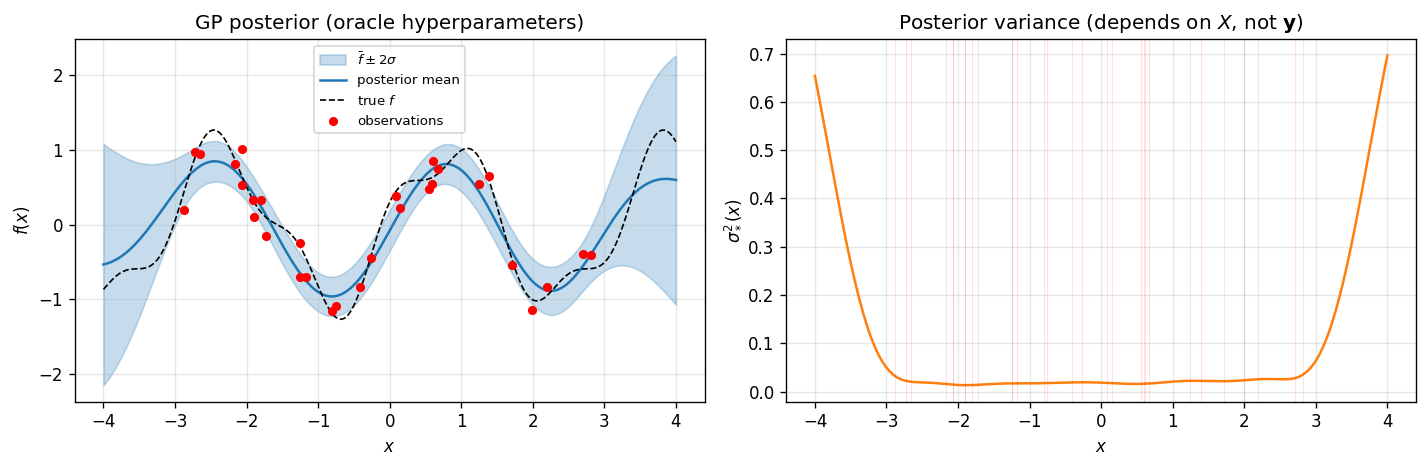

In [3]:
# Regression demo
np.random.seed(42)
f_true = lambda x: np.sin(2 * x) + 0.3 * np.cos(5 * x)
noise_std = 0.2

X_train = np.sort(np.random.uniform(-3, 3, 30)).reshape(-1, 1)
y_train = f_true(X_train.ravel()) + noise_std * np.random.randn(len(X_train))
X_test = np.linspace(-4, 4, 300).reshape(-1, 1)

cfg = make_config(lmbda=noise_std**2)
gp = DenseGP(cfg, np.array([1.0]))
gp.fit(X_train, y_train)
mu, std = gp.predict(X_test, return_std=True)
mu, std = np.asarray(mu), np.asarray(std)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.fill_between(
    X_test.ravel(),
    mu - 2 * std,
    mu + 2 * std,
    alpha=0.25,
    color="C0",
    label=r"$\bar{f} \pm 2\sigma$",
)
ax.plot(X_test, mu, "C0", linewidth=1.5, label="posterior mean")
ax.plot(X_test, f_true(X_test.ravel()), "k--", linewidth=1, label="true $f$")
ax.scatter(X_train, y_train, c="red", s=20, zorder=5, label="observations")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("GP posterior (oracle hyperparameters)")
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.plot(X_test, std**2, "C1", linewidth=1.5)
for xi in X_train.ravel():
    ax2.axvline(xi, color="red", alpha=0.15, linewidth=0.5)
ax2.set_xlabel("$x$")
ax2.set_ylabel(r"$\sigma^2_*(x)$")
ax2.set_title(r"Posterior variance (depends on $X$, not $\mathbf{y}$)")

plt.tight_layout()
plt.show()

## Hyperparameters

The formulas above assume $k$ and $\lambda$ are known. In practice they have free parameters:

| Parameter | Controls |
|-----------|----------|
| $\sigma_i$ (length scale, per dim) | How far you move in dim $i$ before $f$ changes. Small -> rugged, large -> flat/smooth. Per-dim $\sigma_i$ = ARD: irrelevant dims get large $\sigma_i$. |
| $\lambda$ (noise variance) | How much noise in $y$. Small -> interpolates every point, large -> smooths through data. |

Getting these right is important, see below. Same data, different $(\sigma, \lambda)$.

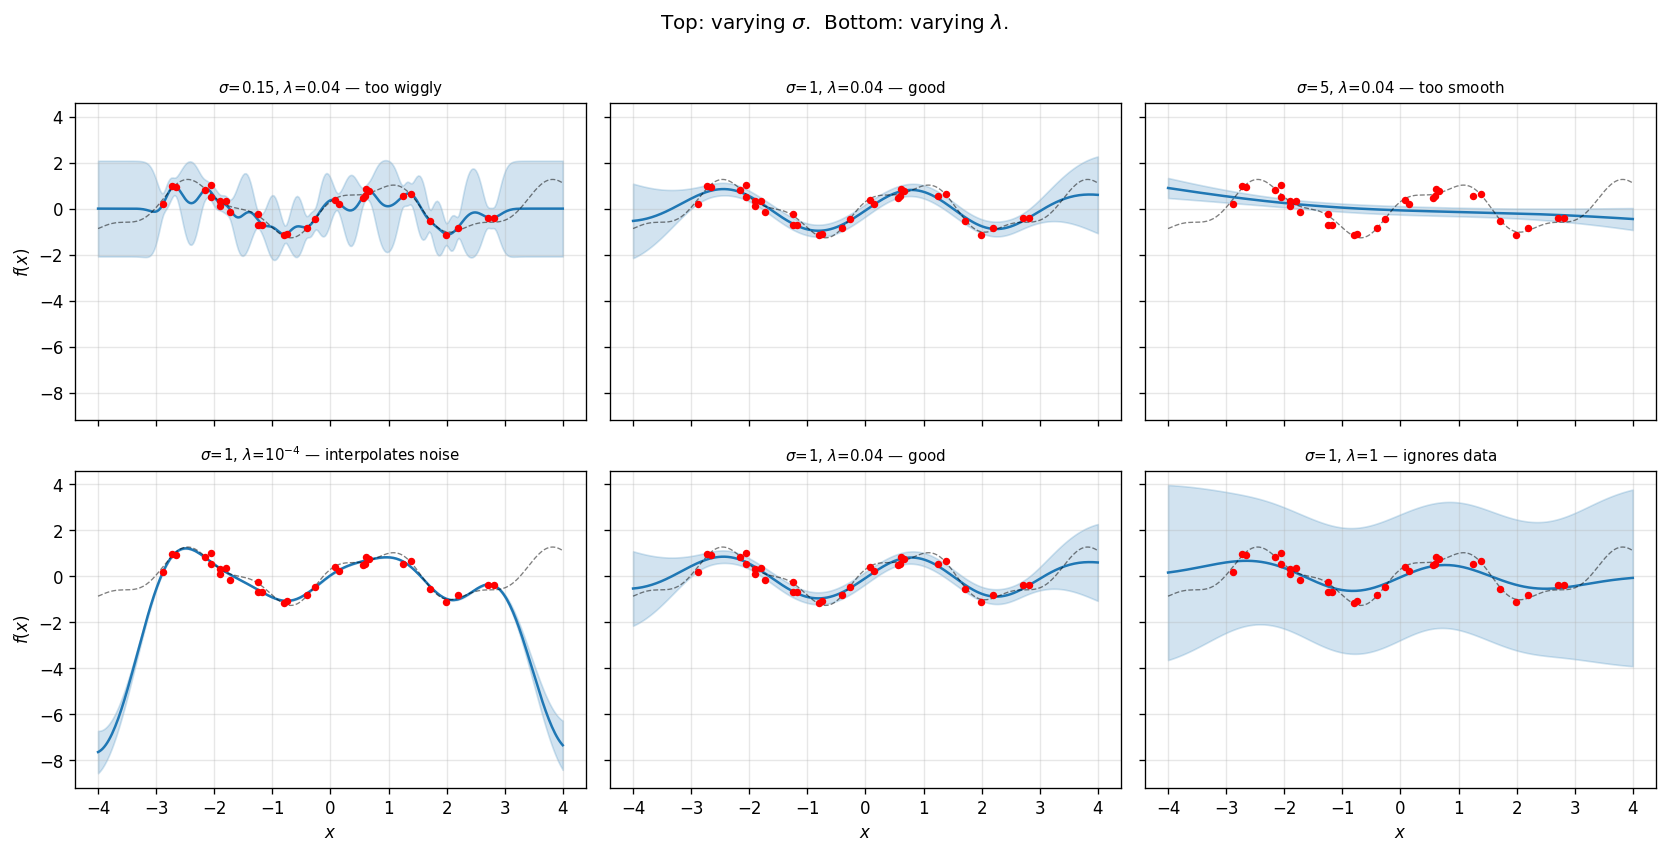

In [4]:
cases = [
    (0.15, 0.04, r"$\sigma\!=\!0.15$, $\lambda\!=\!0.04$ — too wiggly"),
    (1.0, 0.04, r"$\sigma\!=\!1$, $\lambda\!=\!0.04$ — good"),
    (5.0, 0.04, r"$\sigma\!=\!5$, $\lambda\!=\!0.04$ — too smooth"),
    (1.0, 1e-4, r"$\sigma\!=\!1$, $\lambda\!=\!10^{-4}$ — interpolates noise"),
    (1.0, 0.04, r"$\sigma\!=\!1$, $\lambda\!=\!0.04$ — good"),
    (1.0, 1.0, r"$\sigma\!=\!1$, $\lambda\!=\!1$ — ignores data"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, (sig, lam, title) in zip(axes.ravel(), cases):
    gp_tmp = DenseGP(make_config(lmbda=lam), np.array([sig]))
    gp_tmp.fit(X_train, y_train)
    mu_t, std_t = gp_tmp.predict(X_test, return_std=True)
    mu_t, std_t = np.asarray(mu_t), np.asarray(std_t)
    ax.fill_between(
        X_test.ravel(), mu_t - 2 * std_t, mu_t + 2 * std_t, alpha=0.2, color="C0"
    )
    ax.plot(X_test, mu_t, "C0", linewidth=1.5)
    ax.plot(X_test, f_true(X_test.ravel()), "k--", linewidth=0.8, alpha=0.5)
    ax.scatter(X_train, y_train, c="red", s=12, zorder=5)
    ax.set_title(title, fontsize=9)
axes[0, 0].set_ylabel("$f(x)$")
axes[1, 0].set_ylabel("$f(x)$")
for ax in axes[1]:
    ax.set_xlabel("$x$")
fig.suptitle(r"Top: varying $\sigma$.  Bottom: varying $\lambda$.", y=1.01)
plt.tight_layout()
plt.show()

## Fitting: marginal likelihood

To choose $\theta = (\sigma_1, \ldots, \sigma_d, \lambda)$ from data, must maximise the **marginal likelihood**. The probability of $\mathbf{y}$ with all functions integrated or marginalised out:

$$p(\mathbf{y} \mid X, \theta) = \mathcal{N}(\mathbf{y} \mid \mathbf{0},\, K_\theta + \lambda I)$$

In log form:

$$\log p(\mathbf{y} \mid \theta) = \underbrace{-\tfrac{1}{2}\,\mathbf{y}^\top(K + \lambda I)^{-1}\mathbf{y}}_{\text{data fit}} \;\underbrace{-\; \tfrac{1}{2}\log|K + \lambda I|}_{\text{complexity}} \;-\; \tfrac{n}{2}\log 2\pi$$

| Term | What |
|------|-------------|
| data fit | Low when $\theta$ explains $\mathbf{y}$ well. A flexible model (short $\sigma$) can always make this small. |
| complexity | $= \sum_i \log(\lambda_i(K) + \lambda)$ where $\lambda_i(K)$ are the eigenvalues of $K$. Eigenvalues measure how much variance the prior allocates to each direction in function space. A flexible model has many large eigenvalues -> high penalty. |

These pull in opposite directions. Short $\sigma$ fits the data but pays a complexity cost. Long $\sigma$ is simple but can't fit. The maximum balances the two, (**Occam's razor**: the data selects the simplest adequate model).

In practice, $d + 1$ parameters means a multi-dim search:
- **Grid search**: fine for low $d$, exponential cost
- **Gradient-based**: $\nabla_\theta \log p(\mathbf{y} \mid \theta)$ is closed-form; use L-BFGS
- **Bayesian optimisation**: what `GPAutoTuner` does

Below: 1D sweep of $\sigma$ (left), 2D grid over $(\sigma, \lambda)$ (middle), and the resulting fit (right).

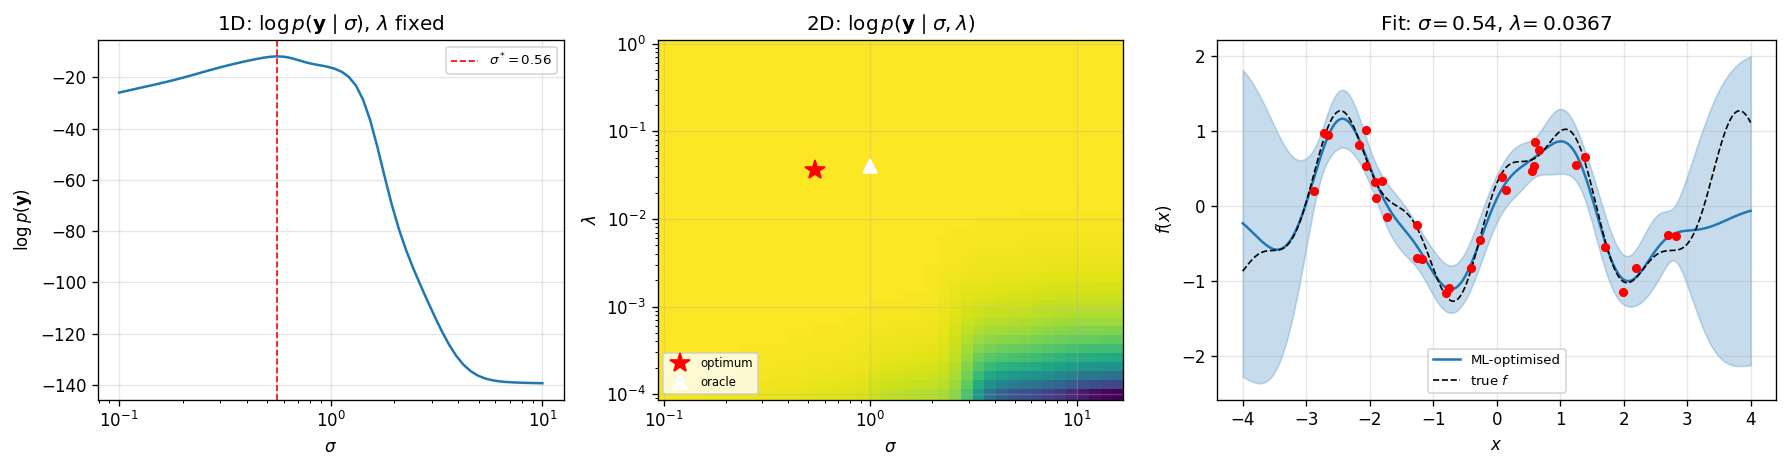

ML-optimised:  sigma=0.541, lmbda=0.03665
Oracle:        sigma=1.000, lmbda=0.04000


In [5]:
def log_ml(X, y, sigma, lmbda):
    """Log marginal likelihood for RBF GP."""
    K = np.array(compute_kernel("RBF", X, X, np.array([sigma])))
    Ky = K + lmbda * np.eye(len(X))
    try:
        L = np.linalg.cholesky(Ky)
    except np.linalg.LinAlgError:
        return -np.inf
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    return (
        -0.5 * y @ alpha - np.sum(np.log(np.diag(L))) - 0.5 * len(y) * np.log(2 * np.pi)
    )


# 1D sweep (fixed lmbda = true noise)
sigmas_1d = np.logspace(-1, 1, 60)
lml_1d = [log_ml(X_train, y_train, s, noise_std**2) for s in sigmas_1d]

# 2D grid search
sigmas_2d = np.logspace(-1, 1.2, 40)
lmbdas_2d = np.logspace(-4, 0, 40)
lml_2d = np.array(
    [[log_ml(X_train, y_train, s, l) for s in sigmas_2d] for l in lmbdas_2d]
)

bi, bj = np.unravel_index(np.argmax(lml_2d), lml_2d.shape)
best_lam, best_sig = lmbdas_2d[bi], sigmas_2d[bj]

# Fit at ML optimum
gp_opt = DenseGP(make_config(lmbda=best_lam), np.array([best_sig]))
gp_opt.fit(X_train, y_train)
mu_opt, std_opt = gp_opt.predict(X_test, return_std=True)
mu_opt, std_opt = np.asarray(mu_opt), np.asarray(std_opt)

# Plot
fig = plt.figure(figsize=(15, 4))
gs = GridSpec(1, 3, width_ratios=[1, 1, 1.2])

ax1 = fig.add_subplot(gs[0])
ax1.plot(sigmas_1d, lml_1d, "C0", linewidth=1.5)
s_best_1d = sigmas_1d[np.argmax(lml_1d)]
ax1.axvline(
    s_best_1d, color="red", ls="--", lw=1, label=rf"$\sigma^*\!={s_best_1d:.2f}$"
)
ax1.set_xscale("log")
ax1.set_xlabel(r"$\sigma$")
ax1.set_ylabel(r"$\log p(\mathbf{y})$")
ax1.set_title(r"1D: $\log p(\mathbf{y} \mid \sigma)$, $\lambda$ fixed")
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[1])
im = ax2.pcolormesh(sigmas_2d, lmbdas_2d, lml_2d, shading="auto", cmap="viridis")
ax2.plot(best_sig, best_lam, "r*", ms=12, label=r"optimum")
ax2.plot(1.0, noise_std**2, "w^", ms=8, label="oracle")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$\sigma$")
ax2.set_ylabel(r"$\lambda$")
ax2.set_title(r"2D: $\log p(\mathbf{y} \mid \sigma, \lambda)$")
ax2.legend(fontsize=7, loc="lower left")

ax3 = fig.add_subplot(gs[2])
ax3.fill_between(
    X_test.ravel(), mu_opt - 2 * std_opt, mu_opt + 2 * std_opt, alpha=0.25, color="C0"
)
ax3.plot(X_test, mu_opt, "C0", linewidth=1.5, label="ML-optimised")
ax3.plot(X_test, f_true(X_test.ravel()), "k--", linewidth=1, label="true $f$")
ax3.scatter(X_train, y_train, c="red", s=20, zorder=5)
ax3.set_xlabel("$x$")
ax3.set_ylabel("$f(x)$")
ax3.set_title(rf"Fit: $\sigma\!={best_sig:.2f}$, $\lambda\!={best_lam:.4f}$")
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"ML-optimised:  sigma={best_sig:.3f}, lmbda={best_lam:.5f}")
print(f"Oracle:        sigma=1.000, lmbda={noise_std**2:.5f}")

## Computational cost

Everything above requires solving $(K + \lambda I)\boldsymbol{\alpha} = \mathbf{y}$ via Cholesky $K + \lambda I = LL^\top$:

| Operation | Cost |
|-----------|------|
| Form $K$ | $\mathcal{O}(n^2 d)$ |
| Cholesky | $\mathcal{O}(n^3/3)$ |
| Solve for $\boldsymbol{\alpha}$ | $\mathcal{O}(n^2)$ |
| Predict mean (one point) | $\mathcal{O}(n)$ |
| Predict variance (one point) | $\mathcal{O}(n^2)$ |
| Log determinant | $\mathcal{O}(n)$ via $2\sum_i \log L_{ii}$ |

The $\mathcal{O}(n^3)$ Cholesky dominates. At $n = 10{,}000$ in float64, $K$ is 800 MB and decomposition is ~$10^{12}$ FLOPs. This motivates sparse approximations.

## Sparse GPs: the Nyström approximation

In Sparse GPs, we approximate the $n \times n$ matrix $K$ using $m \ll n$ **inducing points** $Z = \{z_1, \ldots, z_m\}$.

With $K_{nm} = k(X, Z)$ and $K_{mm} = k(Z, Z)$, the **Nyström approximation** is:

$$\tilde{K} = K_{nm} K_{mm}^{-1} K_{mn}$$

This is rank $m$, so the bottleneck shifts from $\mathcal{O}(n^3)$ to $\mathcal{O}(nm^2)$, (**linear in $n$** for fixed $m$).

### Quality

$\tilde{K}$ is the projection of $K$ onto the subspace spanned by the kernel evaluations at $Z$. Since it's a projection, $K - \tilde{K} \succeq 0$ (+ve semi-definite), and quality is measured by:

$$\text{residual} = \frac{\mathrm{tr}(K - \tilde{K})}{\mathrm{tr}(K)}$$

When eigenvalues of $K$ decay fast (smooth kernels, clustered data), a small $m$ captures most of the structure.

| | Dense | Nyström |
|--|-------|---------|
| Kernel | $\mathcal{O}(n^2 d)$ | $\mathcal{O}(nmd)$ |
| Decomposition | $\mathcal{O}(n^3)$ | $\mathcal{O}(nm^2)$ |
| Storage | $\mathcal{O}(n^2)$ | $\mathcal{O}(nm)$ |

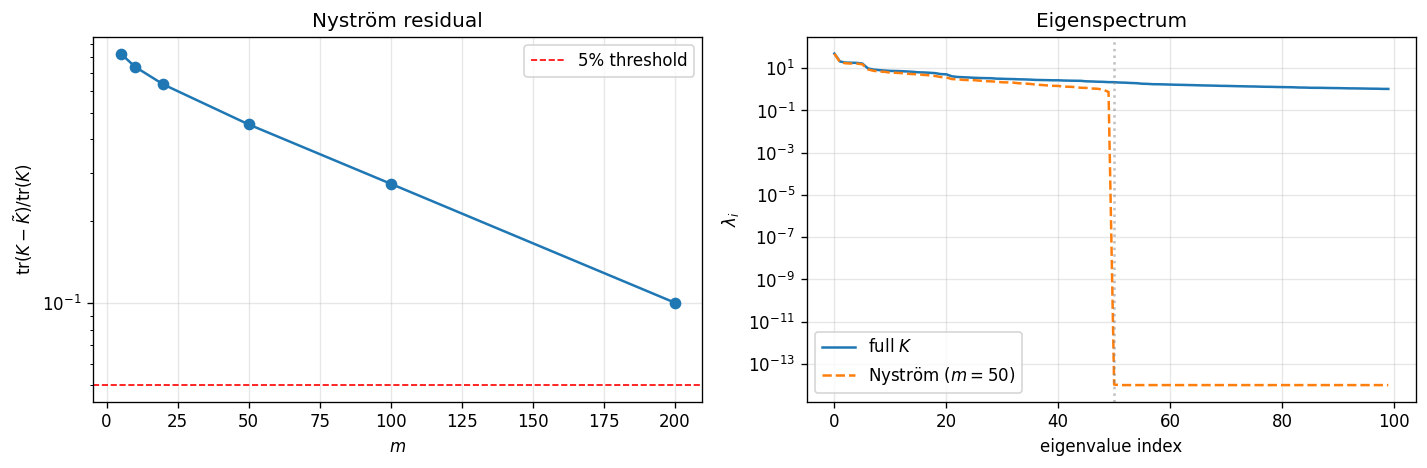

In [6]:
np.random.seed(42)
n_pts = 500
X_nys = np.random.randn(n_pts, 5)
sigma_nys = jnp.ones(5)
K_full = np.asarray(compute_kernel("RBF", X_nys, X_nys, sigma_nys))
tr_K = np.trace(K_full)

ms = [5, 10, 20, 50, 100, 200]
residuals = []
for m in ms:
    Z = get_inducing_selector("kmeans", m).select(X_nys)
    Knm = np.asarray(compute_kernel("RBF", X_nys, Z, sigma_nys))
    Kmm = np.array(compute_kernel("RBF", Z, Z, sigma_nys)) + 1e-6 * np.eye(m)
    Q = Knm @ np.linalg.inv(Kmm) @ Knm.T
    residuals.append((tr_K - np.trace(Q)) / tr_K)

# Eigenvalue comparison
m_demo = 50
Z_demo = get_inducing_selector("kmeans", m_demo).select(X_nys)
Knm_d = np.asarray(compute_kernel("RBF", X_nys, Z_demo, sigma_nys))
Kmm_d = np.array(compute_kernel("RBF", Z_demo, Z_demo, sigma_nys)) + 1e-6 * np.eye(
    m_demo
)
Q_demo = Knm_d @ np.linalg.inv(Kmm_d) @ Knm_d.T
eigs_full = np.sort(np.linalg.eigvalsh(K_full))[::-1]
eigs_nys = np.sort(np.linalg.eigvalsh(Q_demo))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(ms, residuals, "o-C0", linewidth=1.5)
axes[0].axhline(0.05, color="red", ls="--", lw=1, label="5% threshold")
axes[0].set_xlabel("$m$")
axes[0].set_ylabel(r"$\mathrm{tr}(K - \tilde{K})/\mathrm{tr}(K)$")
axes[0].set_title("Nyström residual")
axes[0].legend()

axes[1].semilogy(np.maximum(eigs_full, 1e-14)[:100], "C0", lw=1.5, label="full $K$")
axes[1].semilogy(
    np.maximum(eigs_nys, 1e-14)[:100], "C1--", lw=1.5, label=f"Nyström ($m={m_demo}$)"
)
axes[1].axvline(m_demo, color="grey", ls=":", alpha=0.5)
axes[1].set_xlabel("eigenvalue index")
axes[1].set_ylabel(r"$\lambda_i$")
axes[1].set_title("Eigenspectrum")
axes[1].legend()
plt.tight_layout()
plt.show()

## FITC: correcting the diagonal

Plain Nyström underestimates marginal variances: $\tilde{k}(x_i, x_i) \leq k(x_i, x_i)$. Points far from inducing points get artificially low variance, (the model is **overconfident**).

**FITC** (fully independent training conditional) fixes this:

$$K_{\mathrm{FITC}} = \underbrace{K_{nm}K_{mm}^{-1}K_{mn}}_{\text{low-rank}} + \underbrace{\Lambda}_{\text{diagonal correction}}$$

where $\Lambda = \mathrm{diag}(K - K_{nm}K_{mm}^{-1}K_{mn}) + \lambda I$. The off-diagonal structure comes from the low-rank term; $\Lambda$ restores the correct marginal variance at each training point, absorbing the approximation error into the noise model.

The generative interpretation: $\mathbf{u} = f(Z) \sim \mathcal{N}(\mathbf{0}, K_{mm})$, and conditioned on $\mathbf{u}$, the training outputs are **independent** (hence "fully independent training conditional"):

$$f_i \mid \mathbf{u} \sim \mathcal{N}\!\big(\mathbf{k}_m(x_i)^\top K_{mm}^{-1}\mathbf{u},\;\; k(x_i,x_i) - \mathbf{k}_m(x_i)^\top K_{mm}^{-1}\mathbf{k}_m(x_i) + \lambda\big)$$

### Solving the FITC system

$K_{\mathrm{FITC}}$ is low-rank + diagonal, so the Woodbury identity gives an $m \times m$ core inversion:

$$(K_{nm}K_{mm}^{-1}K_{mn} + \Lambda)^{-1} = \Lambda^{-1} - \Lambda^{-1}K_{nm}\underbrace{(K_{mm} + K_{mn}\Lambda^{-1}K_{nm})}_{m \times m}{}^{-1}K_{mn}\Lambda^{-1}$$

Cost: $\mathcal{O}(nm^2 + m^3)$.

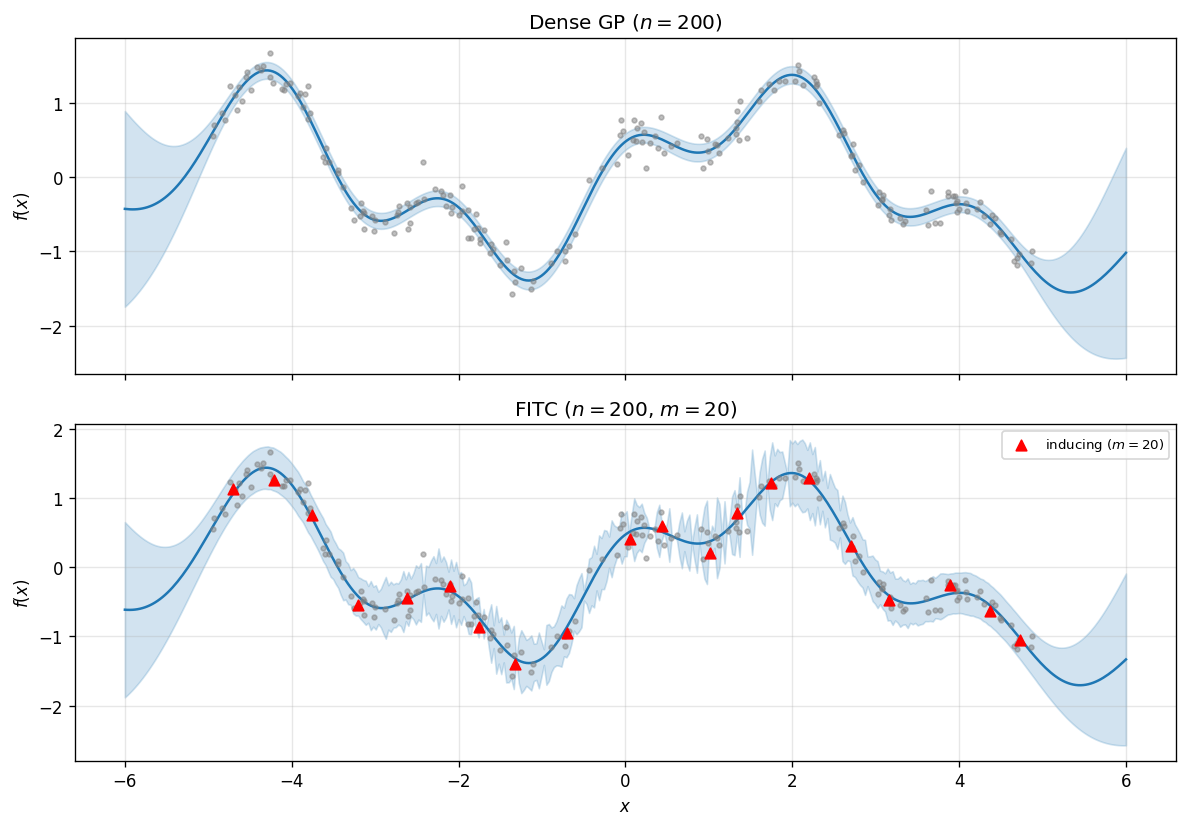

In [7]:
np.random.seed(42)
n_tr = 200
X_tr = np.sort(np.random.uniform(-5, 5, n_tr)).reshape(-1, 1)
y_tr = (
    np.sin(X_tr.ravel()) + 0.5 * np.cos(3 * X_tr.ravel()) + 0.15 * np.random.randn(n_tr)
)
X_te = np.linspace(-6, 6, 400).reshape(-1, 1)
sig1 = np.array([1.0])

gp_d = DenseGP(make_config(lmbda=0.02), sig1)
gp_d.fit(X_tr, y_tr)
mu_d, std_d = gp_d.predict(X_te, return_std=True)
mu_d, std_d = np.asarray(mu_d), np.asarray(std_d)

gp_f = FITCGP(make_config(lmbda=0.02, use_sparse=True, num_inducing=20), sig1)
gp_f.fit(X_tr, y_tr, inducing_method="kmeans")
mu_f, std_f = gp_f.predict(X_te, return_std=True)
mu_f, std_f = np.asarray(mu_f), np.asarray(std_f)
Z = np.asarray(gp_f.Z)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for ax, mu_p, std_p, title in [
    (axes[0], mu_d, std_d, f"Dense GP ($n={n_tr}$)"),
    (axes[1], mu_f, std_f, f"FITC ($n={n_tr}$, $m={len(Z)}$)"),
]:
    ax.fill_between(
        X_te.ravel(), mu_p - 2 * std_p, mu_p + 2 * std_p, alpha=0.2, color="C0"
    )
    ax.plot(X_te, mu_p, "C0", linewidth=1.5)
    ax.scatter(X_tr, y_tr, c="grey", s=8, alpha=0.5, zorder=3)
    ax.set_title(title)
    ax.set_ylabel("$f(x)$")

axes[1].scatter(
    Z,
    np.interp(Z.ravel(), X_tr.ravel(), y_tr),
    c="red",
    s=40,
    marker="^",
    zorder=5,
    label=f"inducing ($m={len(Z)}$)",
)
axes[1].legend(fontsize=8)
axes[1].set_xlabel("$x$")
plt.tight_layout()
plt.show()

## Inducing point selection

How the inducing points $Z$ are chosen matters.

| Method | Strategy | Cost |
|--------|----------|------|
| **Random** | Subsample from $X$ | $\mathcal{O}(1)$ |
| **K-means** | Cluster centroids of $X$ | $\mathcal{O}(nmk)$/iter |
| **K-means++** | Distance-based greedy seeding | Same as k-means |
| **Furthest point** | Max-min distance greedy | $\mathcal{O}(nm)$ |

K-means places inducing points where the data is dense. For stationary kernels this is effective: the leading eigenvectors of $K$ vary most in high-density regions, so centroids there capture the dominant eigenspace.

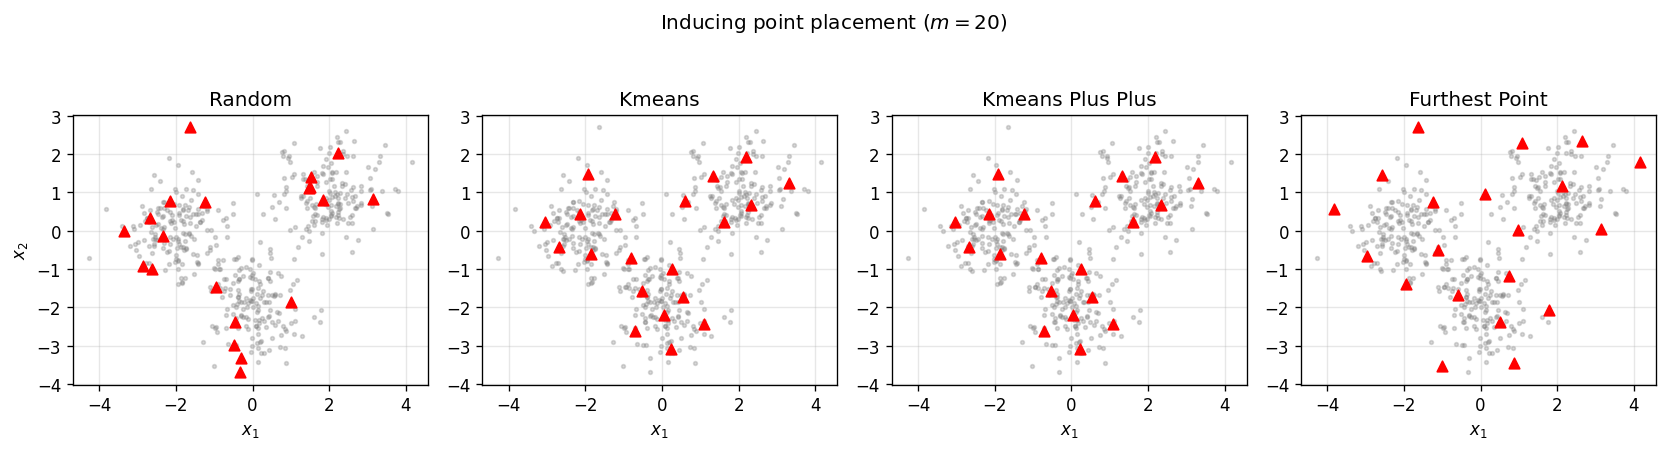

In [8]:
np.random.seed(42)
centers = np.array([[-2, 0], [2, 1], [0, -2.0]])
X_2d = np.vstack([c + 0.7 * np.random.randn(166, 2) for c in centers])

methods = ["random", "kmeans", "kmeans_plus_plus", "furthest_point"]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, method in zip(axes, methods):
    Z_sel = get_inducing_selector(method, 20).select(X_2d)
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c="grey", s=5, alpha=0.3)
    ax.scatter(Z_sel[:, 0], Z_sel[:, 1], c="red", s=40, marker="^", zorder=5)
    ax.set_title(method.replace("_", " ").title())
    ax.set_xlabel("$x_1$")
    ax.set_aspect("equal")
axes[0].set_ylabel("$x_2$")
plt.suptitle("Inducing point placement ($m = 20$)", y=1.02)
plt.tight_layout()
plt.show()

## Scaling and accuracy–cost tradeoff

For fixed $m$, FITC is $\mathcal{O}(nm^2)$, (**linear in $n$**). Increasing $m$ improves accuracy but costs $\mathcal{O}(m^2)$ more. For a nested sequence $Z_1 \subset Z_2 \subset \cdots$ the residual is guaranteed to decrease; k-means recomputes all centroids so it's not strictly monotone but trends down.

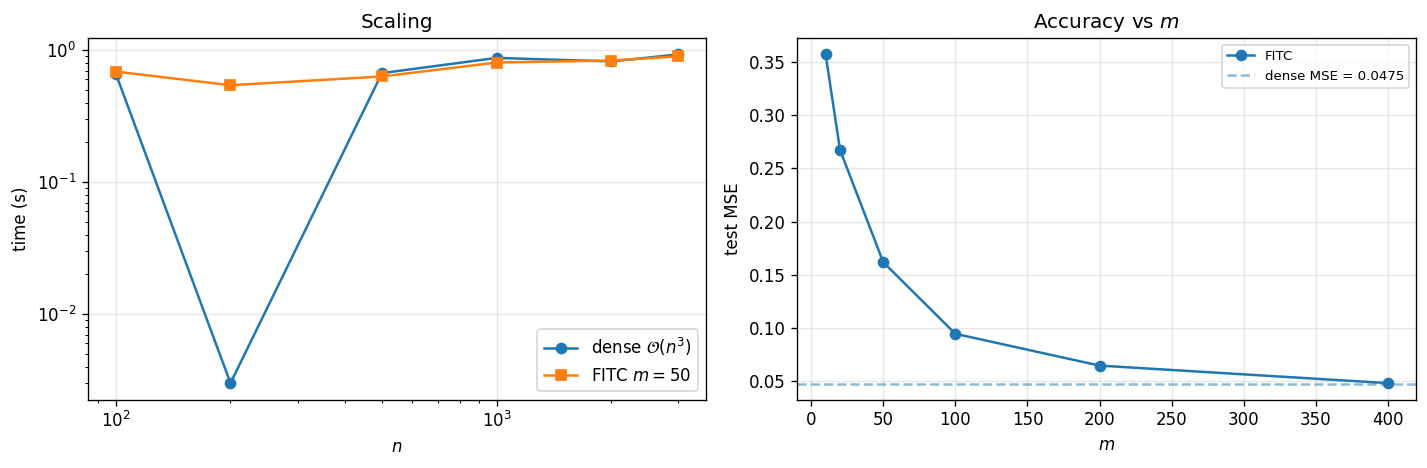

In [9]:
np.random.seed(42)
d_sc = 5
m_fix = 50
sigma_sc = np.ones(d_sc)
sizes = [100, 200, 500, 1000, 2000, 3000]

# warmup
X_w, y_w = np.random.randn(50, d_sc), np.random.randn(50)
DenseGP(make_config(lmbda=0.01), sigma_sc).fit(X_w, y_w)
FITCGP(make_config(lmbda=0.01, use_sparse=True, num_inducing=m_fix), sigma_sc).fit(
    X_w, y_w
)

t_dense, t_fitc = [], []
for n in sizes:
    X_t = np.random.randn(n, d_sc)
    y_t = np.sin(X_t[:, 0]) + 0.1 * np.random.randn(n)
    t0 = time.perf_counter()
    DenseGP(make_config(lmbda=0.01), sigma_sc).fit(X_t, y_t)
    t_dense.append(time.perf_counter() - t0)
    t0 = time.perf_counter()
    FITCGP(make_config(lmbda=0.01, use_sparse=True, num_inducing=m_fix), sigma_sc).fit(
        X_t, y_t, inducing_method="kmeans"
    )
    t_fitc.append(time.perf_counter() - t0)

# accuracy vs m
n_a = 1000
X_a = np.random.randn(n_a, d_sc)
y_a = np.sin(X_a[:, 0]) + 0.3 * X_a[:, 1] ** 2 + 0.1 * np.random.randn(n_a)
Xatr, Xate, yatr, yate = X_a[:800], X_a[800:], y_a[:800], y_a[800:]
gp_ref = DenseGP(make_config(lmbda=0.01), np.ones(d_sc))
gp_ref.fit(Xatr, yatr)
mse_ref = np.mean((yate - np.asarray(gp_ref.predict(Xate))) ** 2)
ms_sw = [10, 20, 50, 100, 200, 400]
mses = []
for m in ms_sw:
    gp_m = FITCGP(
        make_config(lmbda=0.01, use_sparse=True, num_inducing=m), np.ones(d_sc)
    )
    gp_m.fit(Xatr, yatr, inducing_method="kmeans")
    mses.append(np.mean((yate - np.asarray(gp_m.predict(Xate))) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].loglog(sizes, t_dense, "o-C0", lw=1.5, label=r"dense $\mathcal{O}(n^3)$")
axes[0].loglog(sizes, t_fitc, "s-C1", lw=1.5, label=rf"FITC $m={m_fix}$")
axes[0].set_xlabel("$n$")
axes[0].set_ylabel("time (s)")
axes[0].set_title("Scaling")
axes[0].legend()

axes[1].plot(ms_sw, mses, "o-C0", lw=1.5, label="FITC")
axes[1].axhline(
    mse_ref, color="C0", ls="--", alpha=0.5, label=f"dense MSE = {mse_ref:.4f}"
)
axes[1].set_xlabel("$m$")
axes[1].set_ylabel("test MSE")
axes[1].set_title("Accuracy vs $m$")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Concolusions

| | Dense GP | FITC |
|--|---------|------|
| Cost | $\mathcal{O}(n^3)$ | $\mathcal{O}(nm^2 + m^3)$ |
| Storage | $\mathcal{O}(n^2)$ | $\mathcal{O}(nm)$ |
| Posterior | Exact | Exact diagonal variance, approximate off-diagonal |
| Hyperparameters | Marginal likelihood | Modified marginal likelihood |

### GP pipeline:

1. Pick a kernel
2. Find optimal $(\sigma, \lambda)$ by maximising the marginal likelihood
3. If $n \gtrsim 2000$, use FITC with $m$ inducing points
4. Predict: posterior mean $\pm$ posterior std